In [10]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns # Seaborn is used for advanced styling of graphs
from sklearn.model_selection import train_test_split
from sklearn.linear_model import LinearRegression
from sklearn.metrics import mean_squared_error

print("Libraries loaded successfully!")

Libraries loaded successfully!


In [11]:
# Load the data
df = pd.read_csv('ai4i2020.csv')

# Show the first 5 rows
df.head()

,UDI,Product ID,Type,Air temperature [K],Process temperature [K],Rotational speed [rpm],Torque [Nm],Tool wear [min],Machine failure,TWF,HDF,PWF,OSF,RNF
0,1,M14860,M,298.1,308.6,1551,42.8,0,0,0,0,0,0,0
1,2,L47181,L,298.2,308.7,1408,46.3,3,0,0,0,0,0,0
2,3,L47182,L,298.1,308.5,1498,49.4,5,0,0,0,0,0,0
3,4,L47183,L,298.2,308.6,1433,39.5,7,0,0,0,0,0,0
4,5,L47184,L,298.2,308.7,1408,40.0,9,0,0,0,0,0,0


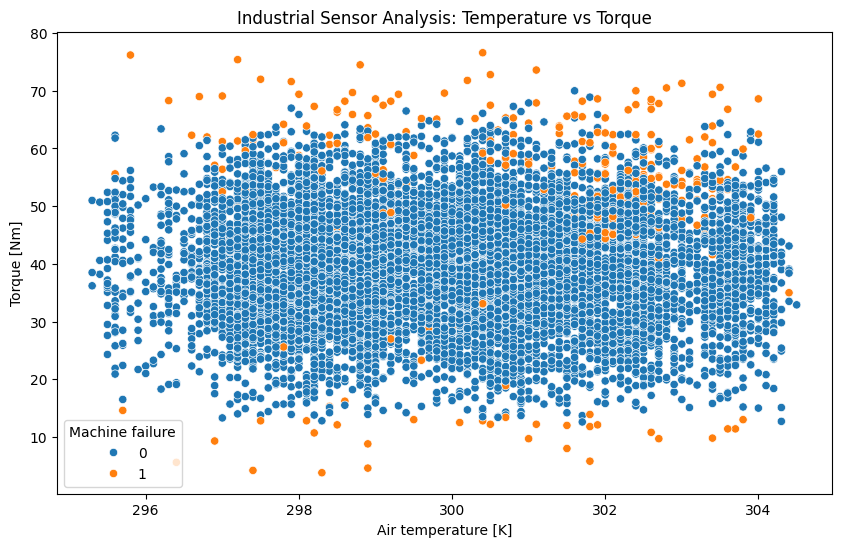

In [12]:
# Create a scatter plot to see how Torque and Temperature relate to failures
plt.figure(figsize=(10, 6))
sns.scatterplot(x='Air temperature [K]', y='Torque [Nm]', hue='Machine failure', data=df)
plt.title('Industrial Sensor Analysis: Temperature vs Torque')
plt.show()

In [13]:
# Select numeric features relevant to mechanical health
features = ['Air temperature [K]', 'Process temperature [K]', 'Rotational speed [rpm]', 'Torque [Nm]', 'Tool wear [min]']
X = df[features]
y = df['Machine failure']

# Split into Training (80%) and Testing (20%) sets
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

In [14]:
# 1. Initialize the Linear Regression model
model = LinearRegression()

# 2. Train the model using our training data
model.fit(X_train, y_train)

# 3. Use the trained model to predict outcomes for the test data
predictions = model.predict(X_test)

In [15]:
# Select the first machine in our test set to see its risk
sample_prediction = predictions[0]
risk_percentage = sample_prediction * 100

print(f"Machine Failure Risk: {risk_percentage:.2f}%")

if risk_percentage > 70:
    print("Decision: URGENT MAINTENANCE REQUIRED")
else:
    print("Decision: Machine is Healthy")

Machine Failure Risk: 2.64%
Decision: Machine is Healthy


In [16]:
import pandas as pd
import numpy as np

print("--- 🛡️ Advanced Industrial Health Monitor ---")

# 1. Capture Inputs
try:
    input_data = {
        'Air temperature [K]': [float(input("Enter Air Temperature [K] (e.g., 300): "))],
        'Process temperature [K]': [float(input("Enter Process Temperature [K] (e.g., 310) "))],
        'Rotational speed [rpm]': [float(input("Enter Rotational Speed [rpm] (e.g., 1500) "))],
        'Torque [Nm]': [float(input("Enter Torque [Nm] (e.g., 40):"))],
        'Tool wear [min]': [float(input("Enter Tool Wear [min] (e.g., 120): "))]
    }

    user_df = pd.DataFrame(input_data)

    # 2. Safety Check: Is the input realistic?
    # Based on the AI4I dataset, RPM rarely exceeds 3000 and Temp rarely exceeds 310
    if input_data['Rotational speed [rpm]'][0] > 5000 or input_data['Air temperature [K]'][0] > 350:
        print("\n⚠️ SENSOR OVERLOAD: Inputs are outside calibrated safety limits.")
        risk_score = 100.0 # Force a danger alert for extreme values
    else:
        # 3. Standard Prediction
        raw_prediction = model.predict(user_df)[0]
        risk_score = max(0, min(100, raw_prediction * 100))

    # 4. Professional Output Formatting
    print(f"\n" + "="*30)
    print(f"DIAGNOSTIC REPORT")
    print(f"Calculated Risk: {risk_score:.2f}%")
    print(f"="*30)

    if risk_score > 80:
        print("🔴 STATUS: CRITICAL - EMERGENCY SHUTDOWN ADVISED")
    elif risk_score > 40:
        print("🟡 STATUS: WARNING - MAINTENANCE REQUIRED")
    else:
        print("🟢 STATUS: OPERATIONAL - NO ANOMALIES DETECTED")

except ValueError:
    print("❌ ERROR: Please enter valid numerical values.")

--- 🛡️ Advanced Industrial Health Monitor ---
Enter Air Temperature [K] (e.g., 300): 800
Enter Process Temperature [K] (e.g., 310) 6223
Enter Rotational Speed [rpm] (e.g., 1500) 212
Enter Torque [Nm] (e.g., 40):111
Enter Tool Wear [min] (e.g., 120): 11

⚠️ SENSOR OVERLOAD: Inputs are outside calibrated safety limits.

DIAGNOSTIC REPORT
Calculated Risk: 100.00%
🔴 STATUS: CRITICAL - EMERGENCY SHUTDOWN ADVISED
